In [4]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

In [5]:
rice_dataset_raw = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/Rice_Cammeo_Osmancik.csv") 

In [7]:
rice_dataset = rice_dataset_raw[['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 'Convex_Area', 'Extent', 'Class']]
rice_dataset.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144753,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


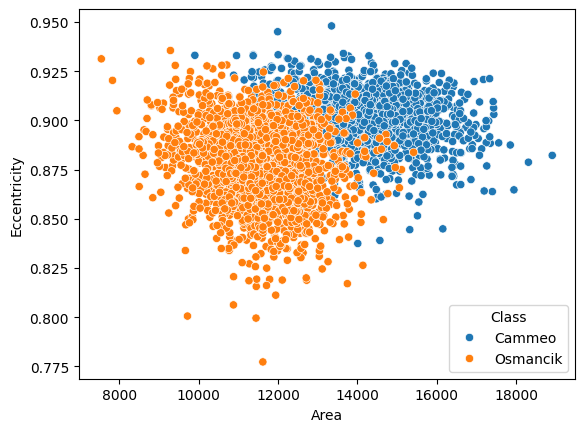

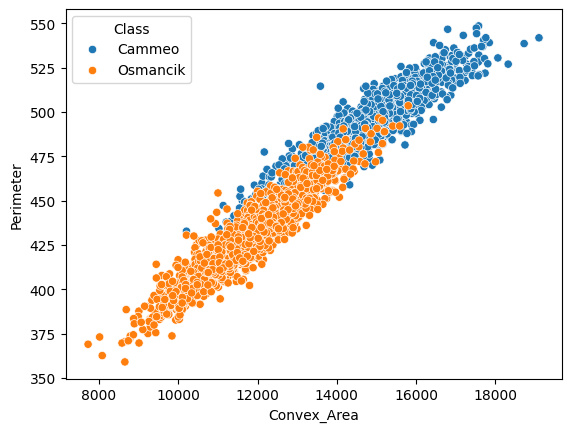

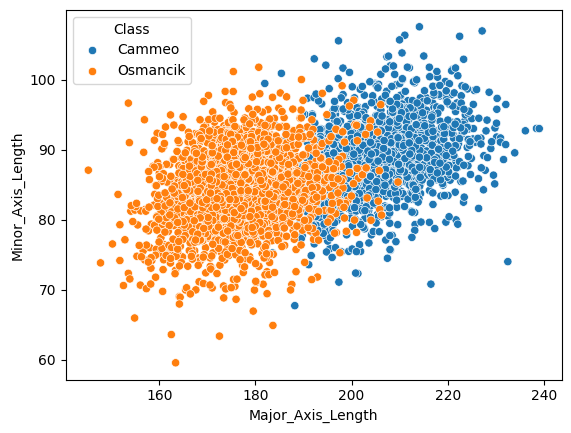

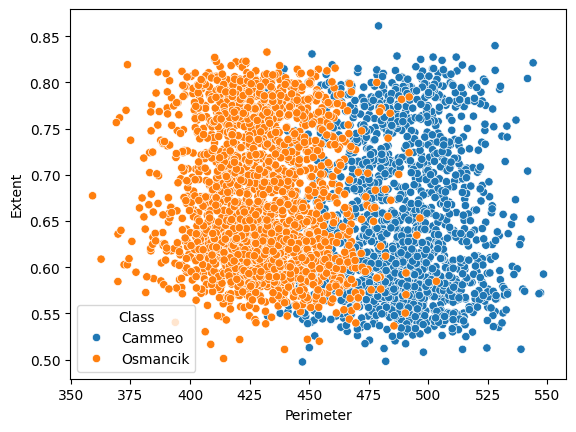

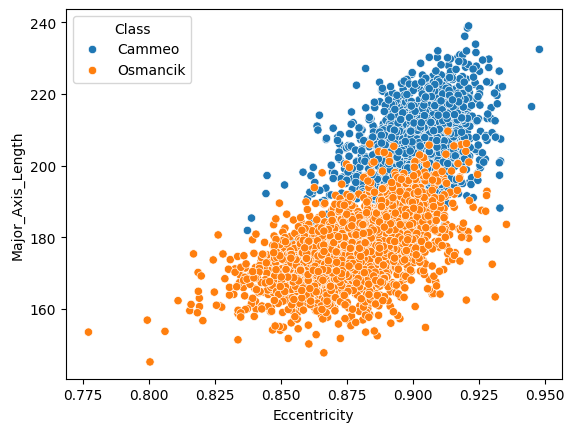

In [8]:
for x_axis_data, y_axis_data in [
    ('Area', 'Eccentricity'),
    ('Convex_Area', 'Perimeter'),
    ('Major_Axis_Length', 'Minor_Axis_Length'),
    ('Perimeter', 'Extent'),
    ('Eccentricity', 'Major_Axis_Length'),
]:
    sns.scatterplot(data=rice_dataset, x=x_axis_data, y=y_axis_data, hue='Class')
    plt.show()

In [11]:
numerical_features = rice_dataset.select_dtypes('number').columns
feature_mean = rice_dataset[numerical_features].mean()
feature_std = rice_dataset[numerical_features].std()
normalized_dataset = (rice_dataset[numerical_features] - feature_mean) / feature_std
normalized_dataset['Class']=rice_dataset['Class']
normalized_dataset.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3.810000e+03,3.810000e+03,3.810000e+03,3.810000e+03,3.810000e+03,3.810000e+03,3.810000e+03
mean,5.967813e-17,-1.790344e-15,-1.074206e-15,1.491953e-16,2.924228e-15,-5.371032e-16,1.790344e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.953604e+00,-2.672668e+00,-2.493699e+00,-4.674031e+00,-5.266589e+00,-2.942926e+00,-2.130034e+00
25%,-7.488177e-01,-7.892340e-01,-8.265593e-01,-6.251605e-01,-6.950351e-01,-7.463521e-01,-8.165818e-01
50%,-1.421335e-01,-1.513238e-01,-1.699936e-01,2.109949e-02,1.046992e-01,-1.384360e-01,-2.145634e-01
75%,7.401849e-01,8.271624e-01,8.467241e-01,6.684203e-01,7.550077e-01,7.493101e-01,8.367238e-01
max,3.605050e+00,2.646475e+00,2.878973e+00,3.704952e+00,2.936761e+00,3.458976e+00,2.577922e+00


In [15]:
normalized_dataset['Class_Bool'] = (
    # Returns true if class is Cammeo, and false if class is Osmancik
    normalized_dataset['Class'] == 'Cammeo'
).astype(int)
normalized_dataset.sample(10)

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_Bool
3334,-1.160682,-1.305561,-1.148447,-0.958787,-0.434201,-1.196697,-0.678485,Osmancik,0
1975,0.168135,0.028874,-0.433639,1.070513,-1.287189,0.237766,-0.514544,Osmancik,0
3676,-0.002152,-0.319919,-0.580111,0.838666,-1.283272,-0.032357,0.222345,Osmancik,0
274,-0.478956,-0.392818,-0.427135,-0.432013,-0.008804,-0.443168,-0.782115,Cammeo,1
3710,-0.797018,-0.699894,-0.967436,-0.166389,-0.906964,-0.761687,-0.929520,Osmancik,0
857,-0.009656,0.374352,0.646132,-0.897245,1.302192,0.021668,-0.878095,Cammeo,1
1118,1.525815,1.510119,1.511016,0.926033,0.860781,1.540544,0.549898,Cammeo,1
3533,-0.360621,-0.367535,-0.759035,0.414411,-1.148053,-0.324427,0.074912,Osmancik,0
2365,-0.713317,-0.844512,-1.037991,0.096281,-1.253458,-0.703723,-0.022467,Osmancik,0
325,1.057669,1.148066,1.462095,0.060623,1.330858,0.990169,-1.045137,Cammeo,1


In [16]:
number_samples = len(normalized_dataset)
index_80th = round(number_samples * 0.8)
index_90th = index_80th + round(number_samples * 0.1)

# Randomize order and split into train, validation, and test with a .8, .1, .1 split
shuffled_dataset = normalized_dataset.sample(frac=1, random_state=100)
train_data = shuffled_dataset.iloc[0:index_80th]
validation_data = shuffled_dataset.iloc[index_80th:index_90th]
test_data = shuffled_dataset.iloc[index_90th:]

# Show the first five rows of the last split
test_data.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_Bool
2405,-0.438549,-0.661183,-0.825462,0.313231,-1.149000,-0.444856,0.341663,Osmancik,0
3062,-0.197838,-0.005342,0.224592,-0.656363,0.802824,-0.207936,1.606695,Osmancik,0
1155,1.381504,1.211330,1.081698,1.176669,0.340787,1.336264,0.710095,Cammeo,1
660,1.165037,1.016005,0.817115,1.311436,-0.002803,1.188822,-0.611756,Cammeo,1
2451,-1.154909,-1.193698,-1.423946,-0.278183,-1.477920,-1.106093,0.053997,Osmancik,0


In [17]:
label_columns = ['Class', 'Class_Bool']

train_features = train_data.drop(columns=label_columns)
train_labels = train_data['Class_Bool'].to_numpy()
validation_features = validation_data.drop(columns=label_columns)
validation_labels = validation_data['Class_Bool'].to_numpy()
test_features = test_data.drop(columns=label_columns)
test_labels = test_data['Class_Bool'].to_numpy()

In [22]:
input_features = [
    'Eccentricity',
    'Major_Axis_Length',
    'Area',
    'Convex_Area',
    'Perimeter',
    'Minor_Axis_Length',
    'Extent',
]

In [23]:
def create_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(input_shape,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy','precision', 'recall', 'AUC']
    )
    return model

def train_model(model, train_features, train_labels, validation_features, validation_labels, epochs=50):
    history = model.fit(
        train_features,
        train_labels,
        epochs=epochs,
        validation_data=(validation_features, validation_labels),
        verbose=1
    )
    return history


In [25]:
model = create_model(len(input_features))
history = train_model(
    model,
    train_features[input_features],
    train_labels,
    validation_features[input_features],
    validation_labels,
    epochs=50
)
results = model.evaluate(test_features[input_features], test_labels, verbose=0)
test_loss = results[0]
test_accuracy = results[1]
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

Epoch 1/50


c:\Users\DD\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - AUC: 0.9602 - accuracy: 0.8546 - loss: 0.3936 - precision: 0.7853 - recall: 0.9365 - val_AUC: 0.9718 - val_accuracy: 0.9134 - val_loss: 0.2148 - val_precision: 0.8908 - val_recall: 0.9172
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - AUC: 0.9739 - accuracy: 0.9212 - loss: 0.2023 - precision: 0.9164 - recall: 0.9049 - val_AUC: 0.9720 - val_accuracy: 0.9160 - val_loss: 0.2148 - val_precision: 0.9006 - val_recall: 0.9112
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - AUC: 0.9804 - accuracy: 0.9289 - loss: 0.1758 - precision: 0.9198 - recall: 0.9185 - val_AUC: 0.9717 - val_accuracy: 0.9186 - val_loss: 0.2165 - val_precision: 0.9107 - val_recall: 0.9053
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9776 - accuracy: 0.9322 - loss: 0.1872 - precision: 0.9246 - recall: 0.9183 - val_AUC: 0.9720 - val_accuracy: 0.9213 - val_loss: 0.2158 - val_precision: 0.9017 - val_recall: 0.9231
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

In [31]:
def evaluate_model(model, validation_features, validation_labels):
    results = model.evaluate(validation_features, validation_labels, verbose=0)
    print(f"Loss: {results[0]:.4f}")
    print(f"Accuracy: {results[1]:.4f}")
    return results[0], results[1]

evaluate_model(model, validation_features, validation_labels)


Loss: 0.3743
Accuracy: 0.8425


(0.3742869198322296, 0.8425197005271912)